# Late Delivery Risk Prediction Modeling Pipeline

Standalone notebook for baseline Logistic Regression, advanced Random Forest, advanced XGBoost, hyperparameter tuning, evaluation, and MLflow tracking.

In [1]:
!pip  install mlflow -q
!pip install dagshub -q
!pip install category_encoders -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.4/49.4 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 77.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 76.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.3/86.3 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 912.3/912.3 kB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214

In [2]:
from google.colab import drive

drive.mount("/content/drive")

import os




os.chdir("/content/drive/MyDrive/um/late_delivery_prediction")
print(os.getcwd())

Mounted at /content/drive
/content/drive/MyDrive/um/late_delivery_prediction


## Imports

In [3]:
import pandas as pd
import numpy as np

from datetime import datetime
from category_encoders import TargetEncoder


from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV,  train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier

import mlflow
import dagshub
import joblib
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

## MLflow Tracking Configuration

In [4]:
DAGSHUB_USERNAME = "sharifa-mohamed"
REPO_NAME = "late_delivery_prediction"
experiment_name = "late_delivery_prediction"


dagshub.init(repo_owner=DAGSHUB_USERNAME, repo_name=REPO_NAME, mlflow=True)

print("\nConnected MLflow Tracking URI:")
print(mlflow.get_tracking_uri())

mlflow.set_experiment(experiment_name)

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=71da49ef-4a37-402d-b855-4f9eebd983b8&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=daf92deacc8366fda50dd22ac1ce2b38c20ec921c001d18468bac5fdef6627d0




Accessing as sharifa-mohamed

Initialized MLflow to track repo "sharifa-mohamed/late_delivery_prediction"

Repository sharifa-mohamed/late_delivery_prediction initialized!


Connected MLflow Tracking URI:
https://dagshub.com/sharifa-mohamed/late_delivery_prediction.mlflow


<Experiment: artifact_location='mlflow-artifacts:/8a7aa0333d8e43219410be10c0d25f4b', creation_time=1780407476578, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1780407476578, lifecycle_stage='active', name='late_delivery_prediction', tags={'mlflow.experimentKind': 'custom_model_development'}, trace_location=None, workspace='default'>

## Load Processed Datasets

In [5]:
# =====================================
# Locate Latest Preprocessing Run Dynamically
# =====================================

preprocessing_exp = mlflow.get_experiment_by_name(experiment_name)

if preprocessing_exp is None:
    raise ValueError(f"Experiment '{experiment_name}' not found.")

# Search specifically for the run named 'data_preparation_pipeline'
runs = mlflow.search_runs(
    experiment_ids=[preprocessing_exp.experiment_id],
    filter_string="tags.mlflow.runName = 'data_preparation_pipeline'",
    order_by=["attributes.start_time DESC"],
    max_results=1
)

if runs.empty:
    raise FileNotFoundError(f"No 'data_preparation_pipeline' runs found for experiment: {experiment_name}")

latest_run_id = runs.iloc[0]["run_id"]

print(f"\nConnected To Run ID: {latest_run_id}")


# =====================================
# Load Dataset Artifacts
# =====================================

print("\nLoading dataset artifacts from MLflow...")

X_train_lr_scaled = pd.read_parquet(
    mlflow.artifacts.download_artifacts(
        run_id=latest_run_id,
        artifact_path="X_train_lr_scaled.parquet"
    )
)

X_test_lr_scaled = pd.read_parquet(
    mlflow.artifacts.download_artifacts(
        run_id=latest_run_id,
        artifact_path="X_test_lr_scaled.parquet"
    )
)

X_train_tree = pd.read_parquet(
    mlflow.artifacts.download_artifacts(
        run_id=latest_run_id,
        artifact_path="X_train_tree.parquet"
    )
)

X_test_tree = pd.read_parquet(
    mlflow.artifacts.download_artifacts(
        run_id=latest_run_id,
        artifact_path="X_test_tree.parquet"
    )
)

y_train = pd.read_parquet(
    mlflow.artifacts.download_artifacts(
        run_id=latest_run_id,
        artifact_path="y_train.parquet"
    )
).squeeze("columns")

y_test = pd.read_parquet(
    mlflow.artifacts.download_artifacts(
        run_id=latest_run_id,
        artifact_path="y_test.parquet"
    )
).squeeze("columns")

print("Dataset artifacts loaded successfully.")

# =====================================
# Load Pipeline Objects
# =====================================

print("\nLoading preprocessing objects...")

categorical_cols = joblib.load(
    mlflow.artifacts.download_artifacts(
        run_id=latest_run_id,
        artifact_path="categorical_cols.pkl"
    )
)

scaler = joblib.load(
    mlflow.artifacts.download_artifacts(
        run_id=latest_run_id,
        artifact_path="scaler.joblib"
    )
)

target_encoder = joblib.load(
    mlflow.artifacts.download_artifacts(
        run_id=latest_run_id,
        artifact_path="target_encoder.joblib"
    )
)

selected_lr_cols = joblib.load(
    mlflow.artifacts.download_artifacts(
        run_id=latest_run_id,
        artifact_path="selected_lr_columns.pkl"
    )
)

print("Preprocessing objects loaded successfully.")

# =====================================
# Verification
# =====================================

print("\n===== Verification Shapes =====")

print(
    f"Logistic Regression Train Shape:"
    f" {X_train_lr_scaled.shape}"
)

print(
    f"Expected LR Columns:"
    f" {len(selected_lr_cols)}"
)

print(
    f"Tree Model Train Shape:"
    f" {X_train_tree.shape}"
)

print(
    f"Target Train Shape:"
    f" {y_train.shape}"
)


Connected To Run ID: 82dafdfcaf7844c295f808f44672e7fd

Loading dataset artifacts from MLflow...


Dataset artifacts loaded successfully.

Loading preprocessing objects...


Preprocessing objects loaded successfully.

===== Verification Shapes =====
Logistic Regression Train Shape: (144415, 32)
Expected LR Columns: 32
Tree Model Train Shape: (144415, 40)
Target Train Shape: (144415,)


## Evaluation Function

In [6]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):

    train_predictions = model.predict(X_train)
    test_predictions = model.predict(X_test)

    train_probabilities = model.predict_proba(X_train)[:, 1]
    test_probabilities = model.predict_proba(X_test)[:, 1]

    metrics = {
        "train_accuracy": accuracy_score(y_train, train_predictions),
        "test_accuracy": accuracy_score(y_test, test_predictions),
        "test_precision": precision_score(y_test, test_predictions),
        "test_recall": recall_score(y_test, test_predictions),
        "test_f1": f1_score(y_test, test_predictions),
        "test_auc": roc_auc_score(y_test, test_probabilities)
    }

    print(f"\n===== {model_name} Performance =====")

    for metric_name, metric_value in metrics.items():
        print(f"{metric_name}: {metric_value:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, test_predictions))

    cm = confusion_matrix(y_test, test_predictions)

    plt.figure(figsize=(6, 5))

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.tight_layout()

    plt.show()

    return metrics

## Baseline Logistic Regression


===== Baseline Logistic Regression Performance =====
train_accuracy: 0.6981
test_accuracy: 0.6972
test_precision: 0.8371
test_recall: 0.5560
test_f1: 0.6682
test_auc: 0.7499

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.87      0.72     16308
           1       0.84      0.56      0.67     19796

    accuracy                           0.70     36104
   macro avg       0.73      0.71      0.69     36104
weighted avg       0.74      0.70      0.69     36104



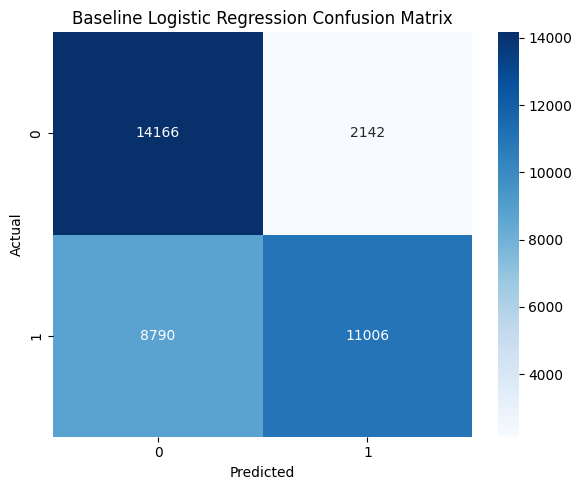

2026/06/09 11:45:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/09 11:45:40 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Baseline Logistic Regression MLflow logging completed.
🏃 View run Baseline_Logistic_Regression at: https://dagshub.com/sharifa-mohamed/late_delivery_prediction.mlflow/#/experiments/1/runs/39fbdc6594b641328ae536ec356467e5
🧪 View experiment at: https://dagshub.com/sharifa-mohamed/late_delivery_prediction.mlflow/#/experiments/1


In [7]:
with mlflow.start_run(run_name="Baseline_Logistic_Regression"):

    mlflow.log_artifact("late_delivery_modeling_pipeline.ipynb")

    baseline_lr = LogisticRegression(
        random_state=42,
        max_iter=1000,
        class_weight="balanced"
    )

    baseline_lr.fit(X_train_lr_scaled, y_train)

    lr_metrics = evaluate_model(
        baseline_lr,
        X_train_lr_scaled,
        y_train,
        X_test_lr_scaled,
        y_test,
        "Baseline Logistic Regression"
    )

    mlflow.log_param("model_type", "LogisticRegression")
    mlflow.log_param("max_iter", 1000)
    mlflow.log_param("class_weight", "balanced")

    for metric_name, metric_value in lr_metrics.items():
        mlflow.log_metric(metric_name, metric_value)

    mlflow.sklearn.log_model(
        baseline_lr,
        artifact_path="baseline_logistic_regression_model"
    )

    print("\nBaseline Logistic Regression MLflow logging completed.")

# Default Random Forest


Default Random Forest Training Started

Training Default Random Forest Model

Evaluating Default Random Forest Model

===== Default Random Forest Performance =====
train_accuracy: 0.9998
test_accuracy: 0.7813
test_precision: 0.8527
test_recall: 0.7266
test_f1: 0.7846
test_auc: 0.8724

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.85      0.78     16308
           1       0.85      0.73      0.78     19796

    accuracy                           0.78     36104
   macro avg       0.79      0.79      0.78     36104
weighted avg       0.79      0.78      0.78     36104



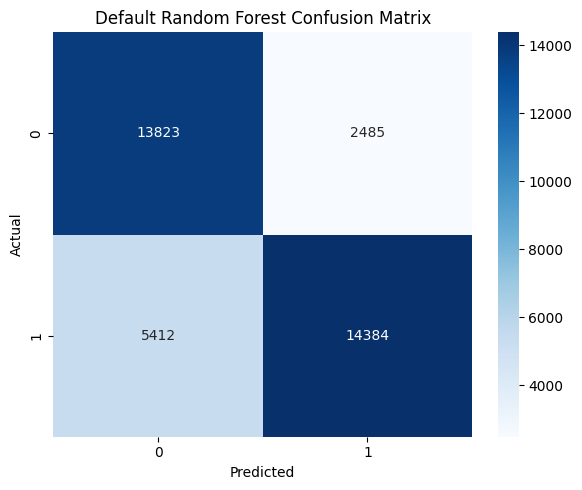


Logging Parameters To MLflow
Logging Metrics To MLflow

Calculating Feature Importance

Top 20 Most Important Features:
                          Feature  Importance
19                  Shipping Mode    0.090628
1   Days for shipment (scheduled)    0.075459
30          customer_avg_discount    0.064653
29       customer_avg_order_value    0.062715
28        customer_total_quantity    0.050784
3                   Customer City    0.045809
27           customer_order_count    0.042940
7                Customer Zipcode    0.038371
10                  Order Country    0.036407
25              discount_per_item    0.033447
24         order_complexity_score    0.032293
16               Order Item Total    0.031547
11            Order Item Discount    0.031505
21           is_high_urgency_mode    0.026718
6                  Customer State    0.026643
12       Order Item Discount Rate    0.026268
20        shipping_pressure_index    0.025774
0                            Type    0.022806
17   

2026/06/09 11:46:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Saving Default Random Forest Model


2026/06/09 11:46:58 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Default Random Forest Training Completed
MLflow Tracking Completed Successfully
🏃 View run RF_Default_20260609_114549 at: https://dagshub.com/sharifa-mohamed/late_delivery_prediction.mlflow/#/experiments/1/runs/be8fa81b14e24b53a720e5981a890d98
🧪 View experiment at: https://dagshub.com/sharifa-mohamed/late_delivery_prediction.mlflow/#/experiments/1


In [8]:
print("\n==========================================")
print("Default Random Forest Training Started")
print("==========================================")

rf_default = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

run_name = f"RF_Default_{datetime.now().strftime('%Y%m%d_%H%M%S')}"

with mlflow.start_run(run_name=run_name):

    mlflow.log_artifact("late_delivery_modeling_pipeline.ipynb")

    print("\nTraining Default Random Forest Model")

    rf_default.fit(X_train_tree, y_train)

    print("\nEvaluating Default Random Forest Model")

    rf_default_metrics = evaluate_model(
        rf_default,
        X_train_tree,
        y_train,
        X_test_tree,
        y_test,
        "Default Random Forest"
    )

    print("\nLogging Parameters To MLflow")

    mlflow.log_param("model_type", "DefaultRandomForest")
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("random_state", 42)

    print("Logging Metrics To MLflow")

    for metric_name, metric_value in rf_default_metrics.items():

        mlflow.log_metric(metric_name, metric_value)

    print("\nCalculating Feature Importance")

    rf_default_feature_importance = pd.DataFrame({
        "Feature": X_train_tree.columns,
        "Importance": rf_default.feature_importances_
    })

    rf_default_feature_importance = rf_default_feature_importance.sort_values(
        "Importance",
        ascending=False
    )

    print("\nTop 20 Most Important Features:")
    print(rf_default_feature_importance.head(20))

    feature_importance_path = "/content/default_random_forest_feature_importance.csv"

    rf_default_feature_importance.to_csv(
        feature_importance_path,
        index=False
    )

    mlflow.log_artifact(
        feature_importance_path,
        artifact_path="feature_importance"
    )


    print("\nSaving Default Random Forest Model")

    mlflow.sklearn.log_model(
        rf_default,
        artifact_path="default_random_forest_model"
    )

    print("\n==========================================")
    print("Default Random Forest Training Completed")
    print("MLflow Tracking Completed Successfully")
    print("==========================================")

# Default XGBoost

In [9]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print(scale_pos_weight)

0.8238592591657089



Default XGBoost Training Started

Training Default XGBoost Model

Evaluating Default XGBoost Model


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [11:47:50] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)



===== Default XGBoost Performance =====
train_accuracy: 0.7574
test_accuracy: 0.7294
test_precision: 0.8462
test_recall: 0.6190
test_f1: 0.7150
test_auc: 0.8142

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.86      0.74     16308
           1       0.85      0.62      0.71     19796

    accuracy                           0.73     36104
   macro avg       0.75      0.74      0.73     36104
weighted avg       0.76      0.73      0.73     36104



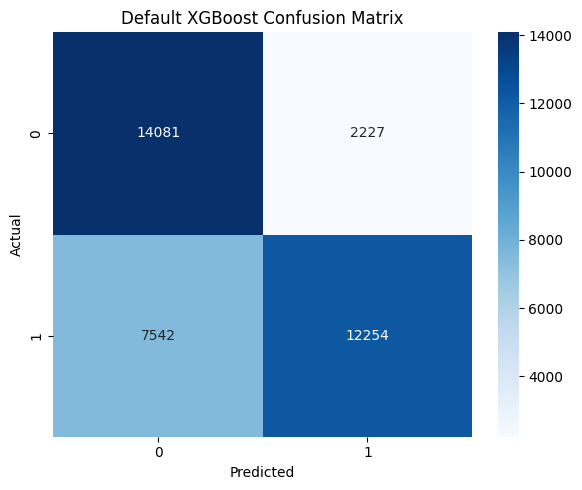


Logging Parameters To MLflow
Logging Metrics To MLflow

Calculating Feature Importance

Top 20 Most Important Features:
                          Feature  Importance
19                  Shipping Mode    0.693790
1   Days for shipment (scheduled)    0.059503
0                            Type    0.032304
3                   Customer City    0.011545
35               region_avg_sales    0.009251
4                Customer Country    0.009152
10                  Order Country    0.009081
5                Customer Segment    0.008707
36            region_avg_discount    0.008623
27           customer_order_count    0.008565
30          customer_avg_discount    0.008538
29       customer_avg_order_value    0.008519
22      regional_congestion_score    0.008492
28        customer_total_quantity    0.008308
6                  Customer State    0.008106
17                   Order Region    0.007933
9                          Market    0.007887
7                Customer Zipcode    0.007845
21   

2026/06/09 11:47:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Saving Default XGBoost Model

Default XGBoost Training Completed
MLflow Tracking Completed Successfully
🏃 View run XGB_Default_20260609_114746 at: https://dagshub.com/sharifa-mohamed/late_delivery_prediction.mlflow/#/experiments/1/runs/d7e28519f2194873860ef6c11c877f28
🧪 View experiment at: https://dagshub.com/sharifa-mohamed/late_delivery_prediction.mlflow/#/experiments/1


In [10]:
print("\n==========================================")
print("Default XGBoost Training Started")
print("==========================================")

xgb_default = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    tree_method="hist",
    device="cuda",
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight
)

run_name = f"XGB_Default_{datetime.now().strftime('%Y%m%d_%H%M%S')}"

with mlflow.start_run(run_name=run_name):

    mlflow.log_artifact("late_delivery_modeling_pipeline.ipynb")

    print("\nTraining Default XGBoost Model")

    xgb_default.fit(X_train_tree, y_train)

    print("\nEvaluating Default XGBoost Model")

    xgb_default_metrics = evaluate_model(
        xgb_default,
        X_train_tree,
        y_train,
        X_test_tree,
        y_test,
        "Default XGBoost"
    )

    print("\nLogging Parameters To MLflow")

    mlflow.log_param("model_type", "DefaultXGBoost")
    mlflow.log_param("eval_metric", "logloss")
    mlflow.log_param("tree_method", "hist")
    mlflow.log_param("device", "cuda")
    mlflow.log_param("random_state", 42)

    print("Logging Metrics To MLflow")

    for metric_name, metric_value in xgb_default_metrics.items():

        mlflow.log_metric(metric_name, metric_value)

    print("\nCalculating Feature Importance")

    xgb_default_feature_importance = pd.DataFrame({
        "Feature": X_train_tree.columns,
        "Importance": xgb_default.feature_importances_
    })

    xgb_default_feature_importance = xgb_default_feature_importance.sort_values(
        "Importance",
        ascending=False
    )

    print("\nTop 20 Most Important Features:")
    print(xgb_default_feature_importance.head(20))


    feature_importance_path = "/content/default_xgb_feature_importance.csv"

    xgb_default_feature_importance.to_csv(
        feature_importance_path,
        index=False
    )

    mlflow.log_artifact(
        feature_importance_path,
        artifact_path="feature_importance"
    )

    print("\nSaving Default XGBoost Model")

    mlflow.xgboost.log_model(
        xgb_default,
        artifact_path="default_xgboost_model"
    )

    print("\n==========================================")
    print("Default XGBoost Training Completed")
    print("MLflow Tracking Completed Successfully")
    print("==========================================")

## Advanced Random Forest With Hyperparameter Tuning


Advanced Random Forest Training Started

Executing structural hyperparameter search...
Fitting 3 folds for each of 40 candidates, totalling 120 fits

Best Structural Parameters Found:
{'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': None, 'criterion': 'entropy'}

Training final high estimator Random Forest...

Final OOB Score: 0.8726

===== Advanced Random Forest Performance =====
train_accuracy: 0.9994
test_accuracy: 0.8766
test_precision: 0.9235
test_recall: 0.8450
test_f1: 0.8825
test_auc: 0.9528

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.92      0.87     16308
           1       0.92      0.85      0.88     19796

    accuracy                           0.88     36104
   macro avg       0.88      0.88      0.88     36104
weighted avg       0.88      0.88      0.88     36104



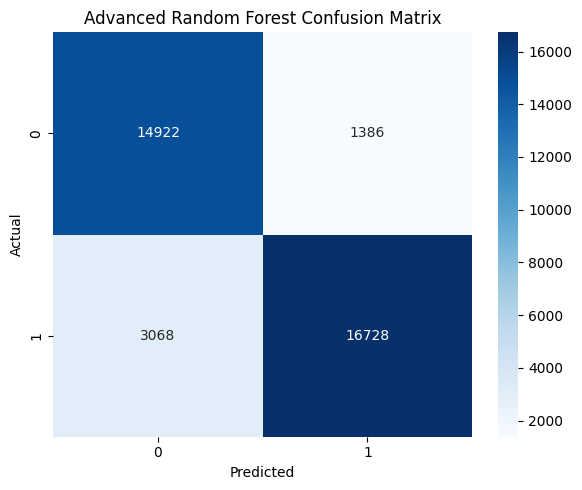

2026/06/09 14:29:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/09 14:29:29 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Advanced Random Forest Training Completed
🏃 View run RF_20260609_114807 at: https://dagshub.com/sharifa-mohamed/late_delivery_prediction.mlflow/#/experiments/1/runs/adda0de187364b46873dbb1154842d59
🧪 View experiment at: https://dagshub.com/sharifa-mohamed/late_delivery_prediction.mlflow/#/experiments/1


In [11]:
# ==========================================
# Advanced Random Forest Training Pipeline
# ==========================================

print("\n==========================================")
print("Advanced Random Forest Training Started")
print("==========================================")

# ==========================================
# Base Random Forest Initialization
# ==========================================

rf_model = RandomForestClassifier(
    n_estimators=150,
    random_state=42,
    n_jobs=None,
    class_weight="balanced",
    oob_score=True,
    bootstrap=True
)

# ==========================================
# Low Estimator Structural Search
# ==========================================



rf_param_grid = {

    "max_depth": [15, 25, 35, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [2, 4, 8],
    "max_features": ["sqrt", 0.2, 0.3, 0.5],
    "criterion": ["gini", "entropy"]
}

rf_random_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=rf_param_grid,
    n_iter=40,
    scoring="roc_auc",
    cv=3,
    verbose=4,
    n_jobs=-1,
    random_state=42
)

run_name = f"RF_{datetime.now().strftime('%Y%m%d_%H%M%S')}"

with mlflow.start_run(run_name=run_name):
    mlflow.log_artifact(
        "late_delivery_modeling_pipeline.ipynb"
    )

    # ==========================================
    # Structural Hyperparameter Search
    # ==========================================

    print("\nExecuting structural hyperparameter search...")

    rf_random_search.fit(X_train_tree, y_train)

    search_best_params = (rf_random_search.best_params_)

    print("\nBest Structural Parameters Found:")
    print(search_best_params)

    # ==========================================
    # Final High Estimator Model
    # ==========================================

    best_rf_model = RandomForestClassifier(
        **search_best_params,
        n_estimators=500,  # Scale upward
        random_state=42,
        n_jobs=-1,
        class_weight="balanced",
        oob_score=True,
        bootstrap=True
    )

    print("\nTraining final high estimator Random Forest...")

    best_rf_model.fit(X_train_tree, y_train)

    print(f"\nFinal OOB Score: {best_rf_model.oob_score_:.4f}" )

    # ==========================================
    # Evaluation
    # ==========================================

    rf_metrics = evaluate_model(
        best_rf_model,
        X_train_tree,
        y_train,
        X_test_tree,
        y_test,
        "Advanced Random Forest"
    )

    # Get predicted probabilities for the positive class
    y_prob = best_rf_model.predict_proba(X_test_tree)[:, 1]

    # ==========================================
    # MLflow Logging
    # ==========================================

    mlflow.log_param("model_type", "RandomForest")
    mlflow.log_param("final_n_estimators", 500)
    mlflow.log_metric("best_cv_auc", rf_random_search.best_score_)
    mlflow.log_metric("oob_score",best_rf_model.oob_score_)


    for param_name, param_value in search_best_params.items():
        mlflow.log_param(param_name, param_value)

    for metric_name, metric_value in rf_metrics.items():
        mlflow.log_metric( metric_name,  metric_value)

    # ==========================================
    # Feature Importance
    # ==========================================

    rf_feature_importance = pd.DataFrame({
        "Feature": X_train_tree.columns,
        "Importance": best_rf_model.feature_importances_
    })

    rf_feature_importance = rf_feature_importance.sort_values("Importance",  ascending=False)
    feature_importance_path = ("/content/random_forest_feature_importance.csv" )
    rf_feature_importance.to_csv(feature_importance_path,  index=False)
    mlflow.log_artifact(feature_importance_path, artifact_path="feature_importance" )

    # ==========================================
    # Save Model
    # ==========================================

    mlflow.sklearn.log_model(best_rf_model, artifact_path="advanced_random_forest_model")

    print("\n==========================================")
    print("Advanced Random Forest Training Completed")
    print("==========================================")



## Advanced XGBoost With Hyperparameter Tuning

Executing structural hyperparameter search via cross-validation...
Fitting 3 folds for each of 40 candidates, totalling 120 fits

Best Structural Parameters Found:
{'subsample': 0.7, 'reg_lambda': 20, 'reg_alpha': 1.0, 'n_estimators': 1000, 'min_child_weight': 5, 'max_depth': 8, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.8}

Training final XGBoost model...

===== Advanced XGBoost Performance =====
train_accuracy: 0.8569
test_accuracy: 0.7642
test_precision: 0.8359
test_recall: 0.7093
test_f1: 0.7674
test_auc: 0.8523

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.83      0.76     16308
           1       0.84      0.71      0.77     19796

    accuracy                           0.76     36104
   macro avg       0.77      0.77      0.76     36104
weighted avg       0.78      0.76      0.76     36104



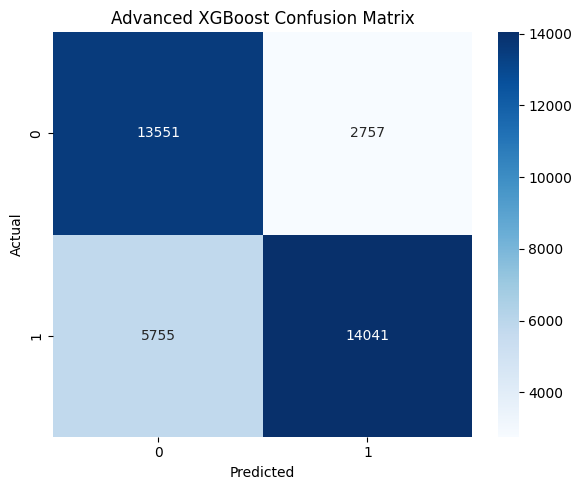


Logging hyperparameter tuned best values to MLflow...


2026/06/09 14:36:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Advanced XGBoost MLflow logging completed successfully.
🏃 View run XGB_20260609_143130 at: https://dagshub.com/sharifa-mohamed/late_delivery_prediction.mlflow/#/experiments/1/runs/0ba9215c5f8e4ff8b4348cfeb21d8ff3
🧪 View experiment at: https://dagshub.com/sharifa-mohamed/late_delivery_prediction.mlflow/#/experiments/1


In [12]:
# ==========================================
# 1. BASE MODEL & HYPERPARAMETER SPACE
# ==========================================

xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    tree_method="hist",
    n_jobs=-1,
    device="cuda",
    scale_pos_weight=scale_pos_weight
)

xgb_param_grid = {
    "n_estimators": [150, 300, 500, 1000],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05],
    "subsample": [0.6, 0.7, 0.8, 0.9],
    "colsample_bytree": [0.5, 0.6, 0.7, 0.8, 0.9],
    "min_child_weight": [1, 3, 5, 7],
    "gamma": [0, 0.1, 0.3, 0.5],
    "reg_alpha": [1.0, 5.0, 10.0],
    "reg_lambda": [5, 10, 20]
}

# ==========================================
# 2. RANDOMIZED SEARCH (CROSS VALIDATION)
# ==========================================

xgb_random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=xgb_param_grid,
    n_iter=40,
    scoring="roc_auc",
    cv=3,
    verbose=4,
    n_jobs=-1,
    random_state=42
)

run_name = f"XGB_{datetime.now().strftime('%Y%m%d_%H%M%S')}"

with mlflow.start_run(run_name=run_name):

    mlflow.log_artifact("late_delivery_modeling_pipeline.ipynb")

    print("Executing structural hyperparameter search via cross-validation...")

    xgb_random_search.fit(X_train_tree, y_train)

    search_best_params = xgb_random_search.best_params_

    print("\nBest Structural Parameters Found:")
    print(search_best_params)

    # ==========================================
    # 3. FINAL MODEL TRAINING
    # ==========================================

    best_xgb_model = XGBClassifier(
        **search_best_params,
        random_state=42,
        eval_metric="logloss",
        tree_method="hist",
        n_jobs=-1,
        device="cuda"
    )

    print("\nTraining final XGBoost model...")

    best_xgb_model.fit(X_train_tree, y_train)

    # ==========================================
    # 4. EVALUATION
    # ==========================================

    xgb_metrics = evaluate_model(
        best_xgb_model,
        X_train_tree,
        y_train,
        X_test_tree,
        y_test,
        "Advanced XGBoost"
    )

    # ==========================================
    # 5. MLFLOW LOGGING
    # ==========================================

    mlflow.log_param("model_type", "XGBoost")
    mlflow.log_metric("best_cv_auc", xgb_random_search.best_score_)

    print("\nLogging hyperparameter tuned best values to MLflow...")

    for param_name, param_value in search_best_params.items():
        mlflow.log_param(param_name, param_value)

    for metric_name, metric_value in xgb_metrics.items():
        mlflow.log_metric(metric_name, metric_value)

    mlflow.xgboost.log_model(
        best_xgb_model,
        artifact_path="advanced_xgboost_model"
    )

    print("\nAdvanced XGBoost MLflow logging completed successfully.")

## Random Forest Feature Importance

In [13]:
rf_feature_importance = pd.DataFrame({
    "Feature": X_train_tree.columns,
    "Importance": best_rf_model.feature_importances_
})

rf_feature_importance = rf_feature_importance.sort_values(
    "Importance",
    ascending=False
)

print("\nTop Random Forest Features:")
print(rf_feature_importance.head(20))


Top Random Forest Features:
                          Feature  Importance
19                  Shipping Mode    0.120491
30          customer_avg_discount    0.088662
29       customer_avg_order_value    0.085666
28        customer_total_quantity    0.059629
1   Days for shipment (scheduled)    0.049023
3                   Customer City    0.048890
27           customer_order_count    0.046465
7                Customer Zipcode    0.044100
10                  Order Country    0.043631
0                            Type    0.032747
25              discount_per_item    0.029489
11            Order Item Discount    0.027594
6                  Customer State    0.025127
24         order_complexity_score    0.022427
16               Order Item Total    0.022141
17                   Order Region    0.021312
12       Order Item Discount Rate    0.021263
36            region_avg_discount    0.018169
35               region_avg_sales    0.017884
21           is_high_urgency_mode    0.017036


## XGBoost Feature Importance

In [14]:
xgb_feature_importance = pd.DataFrame({
    "Feature": X_train_tree.columns,
    "Importance": best_xgb_model.feature_importances_
})

xgb_feature_importance = xgb_feature_importance.sort_values(
    "Importance",
    ascending=False
)

print("\nTop XGBoost Features:")
print(xgb_feature_importance.head(20))


Top XGBoost Features:
                          Feature  Importance
19                  Shipping Mode    0.460194
1   Days for shipment (scheduled)    0.145267
21           is_high_urgency_mode    0.032812
0                            Type    0.025891
3                   Customer City    0.013978
29       customer_avg_order_value    0.012408
27           customer_order_count    0.012283
30          customer_avg_discount    0.012236
10                  Order Country    0.012160
28        customer_total_quantity    0.012015
6                  Customer State    0.011509
17                   Order Region    0.011411
35               region_avg_sales    0.011406
36            region_avg_discount    0.011314
34            region_order_volume    0.011151
22      regional_congestion_score    0.011042
5                Customer Segment    0.011037
7                Customer Zipcode    0.011036
9                          Market    0.010552
20        shipping_pressure_index    0.009012
